# Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving dataset.csv to dataset.csv


In [ ]:
uploaded.keys()


dict_keys(['dataset.csv'])

In [ ]:
import pandas as pd
df = pd.read_csv("dataset.csv", encoding='utf-8')

# Exploratory Data Analysis

In [ ]:
print(df.shape)
df.columns

(22000, 2)


Index(['Text', 'language'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      22000 non-null  object
 1   language  22000 non-null  object
dtypes: object(2)
memory usage: 343.9+ KB


In [ ]:
df.describe()

,Text,language
count,22000,22000
unique,21859,22
top,haec commentatio automatice praeparata res ast...,Estonian
freq,48,1000


### Dataset has duplicated values

In [ ]:
# identify duplicates
df.duplicated().sum()

np.int64(141)

In [ ]:
# display all duplicates
df[df['Text'].duplicated(keep=False)].sort_values('Text')

,Text,language
12915,ईसा पूर्व ईसा मसीह के जन्म से पूर्व के वर्षों...,Hindi
6404,ईसा पूर्व ईसा मसीह के जन्म से पूर्व के वर्षों...,Hindi
1846,ईसा पूर्व ईसा मसीह के जन्म से पूर्व के वर्षों...,Hindi
13141,ईसा पूर्व ईसा मसीह के जन्म से पूर्व के वर्षों...,Hindi
7244,ईसा पूर्व ईसा मसीह के जन्म से पूर्व के वर्षों...,Hindi
...,...,...
14499,இக்கோயில் முதன்மைத் திருக்கோயில் என்ற வகைப்பாட...,Tamil
8478,இக்கோயில் முதன்மைத் திருக்கோயில் என்ற வகைப்பாட...,Tamil
8222,இவ்வூர் கடல்மட்டத்தில் இருந்து சராசரியாக மீட்...,Tamil
21739,இவ்வூர் கடல்மட்டத்தில் இருந்து சராசரியாக மீட்...,Tamil


In [ ]:
# delete duplicates and keep only one instance of each repeated values
df = df.drop_duplicates(subset='Text', keep='first').reset_index(drop=True)

In [ ]:
# confirm no duplicates exist
df.duplicated(keep=False).sum()

np.int64(0)

### Ceck for Class Imbalance

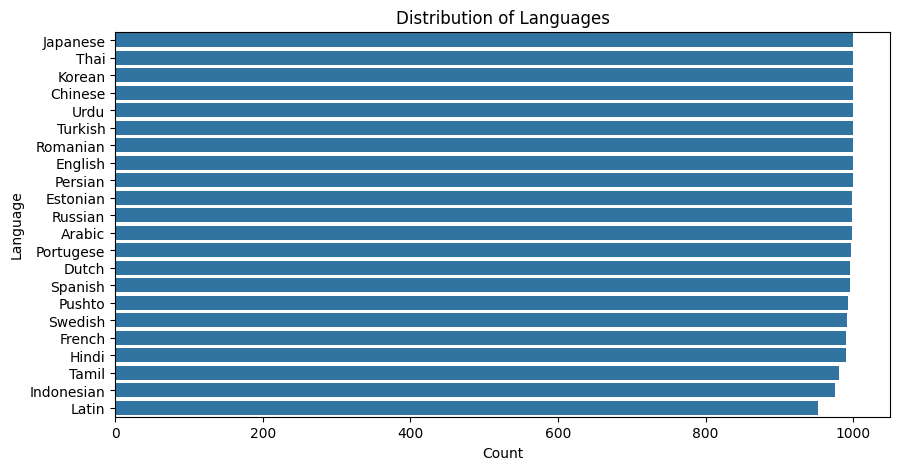

In [ ]:
# check class balance
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(y='language', data=df, order=df['language'].value_counts().index)
plt.title('Distribution of Languages')
plt.xlabel('Count')
plt.ylabel('Language')
plt.show()

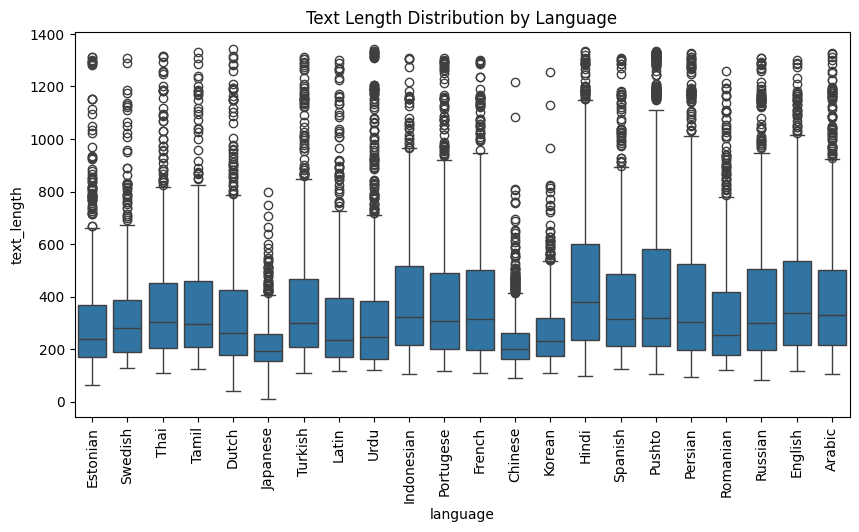

In [ ]:
# check for text length according to each language
df['text_length'] = df['Text'].apply(len)
plt.figure(figsize=(10,5))
sns.boxplot(x='language', y='text_length', data=df)
plt.xticks(rotation=90)
plt.title('Text Length Distribution by Language')
plt.show()

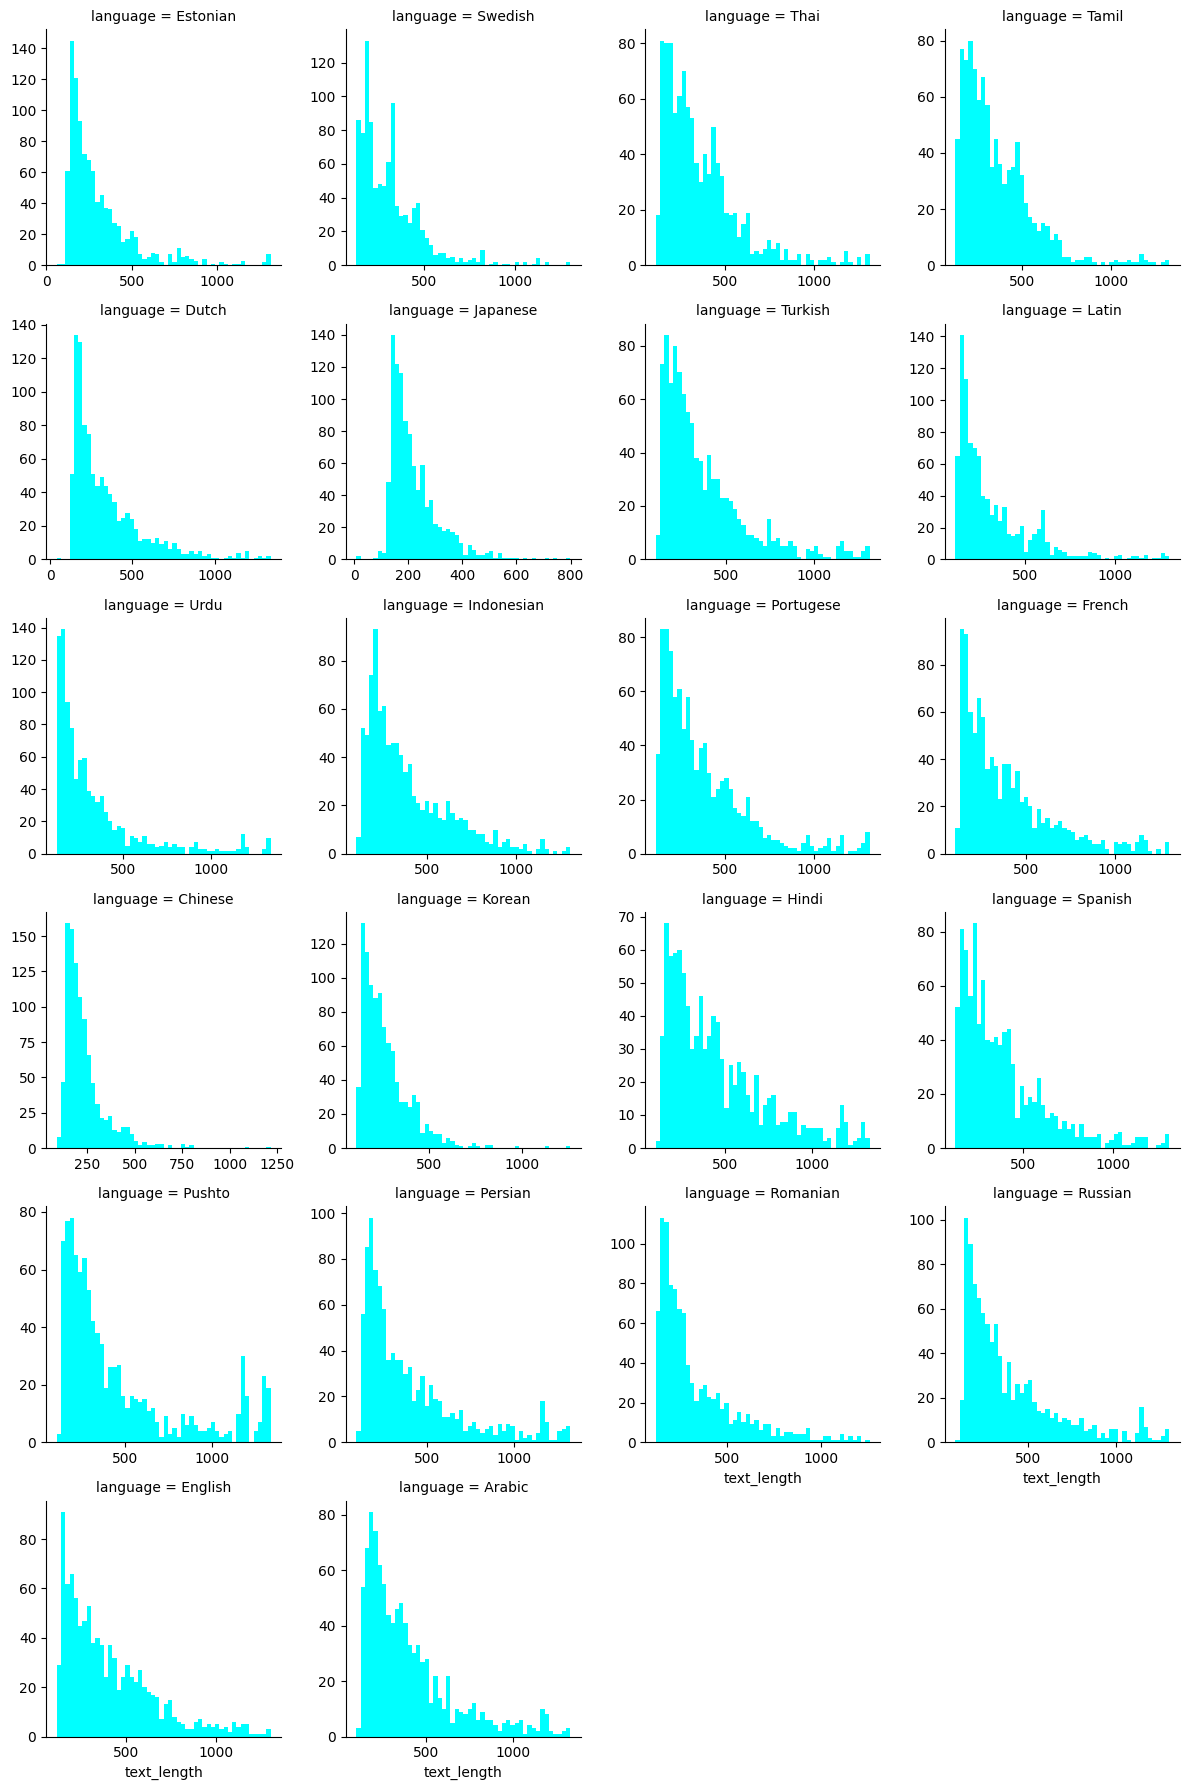

In [ ]:
# display text length for each language in individual hitsograms
import seaborn as sns
import matplotlib.pyplot as plt

df['text_length'] = df['Text'].apply(len)

g = sns.FacetGrid(df, col="language", col_wrap=4, sharex=False, sharey=False)
g.map(plt.hist, "text_length", bins=50, color="cyan")

plt.show()

In [ ]:
df['language'].value_counts()

,count
language,
Japanese,1000
Thai,1000
Korean,1000
Chinese,1000
Urdu,1000
Turkish,1000
Romanian,1000
English,1000
Persian,1000


In [ ]:
# check for noise in the data (emojis, URLs, Numbers, Punctuation)
!pip install emoji
import re
import string
import emoji
def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

def contains_url(text):
    return re.search(r'http\S+', text) is not None

def contains_number(text):
    return any(char.isdigit() for char in text)

def contains_punctuation(text):
    return any(char in string.punctuation for char in text)

df['has_emoji'] = df['Text'].apply(contains_emoji)
df['has_url'] = df['Text'].apply(contains_url)
df['has_number'] = df['Text'].apply(contains_number)
df['has_punctuation'] = df['Text'].apply(contains_punctuation)

print("URLs in data: ", df['has_url'].sum())
print("Numbers in data: ", df['has_number'].sum())
print("Emojis in data: ", df['has_emoji'].sum())
print("Punctuation in data: ", df['has_punctuation'].sum())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.3 MB/s eta 0:00:00
URLs in data:  3
Numbers in data:  107
Emojis in data:  4
Punctuation in data:  8235


In [ ]:
# remove samples with URLs and Emojis noise
# punctuation and numbers can help in the classification task because different languages use different numbring systems
df = df.drop(df[(df['has_url'] == True) | (df['has_emoji'] == True)].index)
df.shape

(21852, 7)

In [ ]:
# drop all the additional columns
df = df.drop(columns=['has_url', 'has_emoji', 'has_number', 'has_punctuation'])
df.shape

(21852, 3)

# Data Preprocessing

In [ ]:
#data preprocessing
def clean_text(text):
    text = str(text)
    text = text.strip()
    text = text.lower()
    return text

df['clean_text'] = df['Text'].apply(clean_text)
df[['Text', 'clean_text']].head()


,Text,clean_text
0,klement gottwaldi surnukeha palsameeriti ning ...,klement gottwaldi surnukeha palsameeriti ning ...
1,sebes joseph pereira thomas på eng the jesuit...,sebes joseph pereira thomas på eng the jesuit...
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...
4,de spons behoort tot het geslacht haliclona en...,de spons behoort tot het geslacht haliclona en...


# Traditional Approch


In [ ]:
#split the dataset into training and testing sets (70% train, 30% test)
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['language']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
#Convert the training and testing text into numerical feature vectors using TF‑IDF
from sklearn.feature_extraction.text import TfidfVectorizer
#character level n‑grams (1 to 3) helps the model capture language-specific patterns
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(1, 3))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

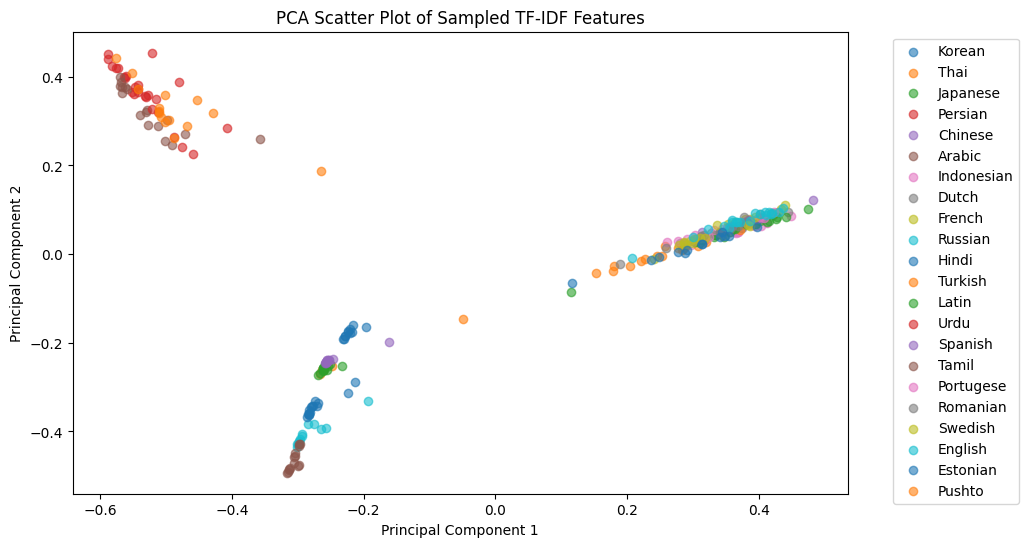

In [ ]:
# visualize a sample from TF-IDF vectors using PCA to display most effective components in the vectors identified by languages
import numpy as np
from sklearn.decomposition import PCA

sample_idx = np.random.choice(X_train_tfidf.shape[0], 300, replace=False)
X_sample = X_train_tfidf[sample_idx].toarray()
y_sample = y_train.iloc[sample_idx]

# apply PCA to reduce TF-IDF vectors to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

# plot the PCA scatter plot
plt.figure(figsize=(10,6))
for lang in y_sample.unique():
    idx = (y_sample == lang).values
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=lang, alpha=0.6)

plt.title('PCA Scatter Plot of Sampled TF-IDF Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
#train a Logistic Regression classifier on the TF‑IDF features
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
#evaluate the model on the test set
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9820012202562538
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       299
     Chinese       0.98      0.99      0.99       300
       Dutch       0.96      0.99      0.98       299
     English       0.79      0.99      0.88       300
    Estonian       0.99      0.97      0.98       299
      French       0.99      0.99      0.99       297
       Hindi       1.00      0.97      0.99       297
  Indonesian       1.00      0.97      0.99       292
    Japanese       1.00      0.99      1.00       300
      Korean       1.00      0.99      0.99       299
       Latin       0.95      0.95      0.95       286
     Persian       0.99      0.99      0.99       300
   Portugese       0.99      0.97      0.98       299
      Pushto       1.00      0.94      0.97       298
    Romanian       1.00      0.99      0.99       300
     Russian       0.99      0.99      0.99       300
     Spanish       1.00      0.97      0.98       29

In [ ]:
#train a Linear Support Vector Machine (SVM) classifier on the TF‑IDF features
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9870347773032336
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       299
     Chinese       0.99      0.99      0.99       300
       Dutch       0.98      0.99      0.99       299
     English       0.83      1.00      0.91       300
    Estonian       0.99      0.97      0.98       299
      French       0.99      1.00      0.99       297
       Hindi       1.00      0.97      0.99       297
  Indonesian       1.00      0.99      1.00       292
    Japanese       1.00      1.00      1.00       300
      Korean       1.00      0.99      0.99       299
       Latin       0.98      0.97      0.98       286
     Persian       1.00      0.99      0.99       300
   Portugese       1.00      0.98      0.99       299
      Pushto       1.00      0.95      0.98       298
    Romanian       1.00      0.99      0.99       300
     Russian       0.99      0.99      0.99       300
     Spanish       1.00      0.98      0.99       29

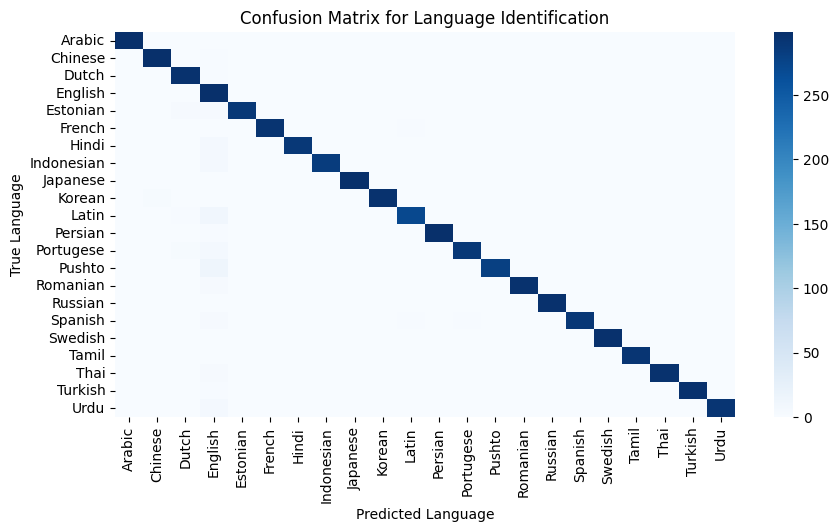

In [ ]:
# evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix for Language Identification")
plt.xlabel("Predicted Language")
plt.ylabel("True Language")
plt.show()

In [ ]:
# test the trained model on a custom input sentence
test_text = ["ہلی جماعت سے پانچویں جماعت تک درس دینے والے دو اسکول ہیں۔ ایک میں ذریعہ تعلیم اردو ہے دوسری میں تلگو"]
# transform the text using the same TF‑IDF vectorizer, then predict its language
test_vector = vectorizer.transform(test_text)
model.predict(test_vector)

array(['Urdu'], dtype=object)

# LLM Approch


### LLM prompt

In [ ]:
# identify the class labels to feed directly into the prompt
print(df['language'].unique())

['Estonian' 'Swedish' 'Thai' 'Tamil' 'Dutch' 'Japanese' 'Turkish' 'Latin'
 'Urdu' 'Indonesian' 'Portugese' 'French' 'Chinese' 'Korean' 'Hindi'
 'Spanish' 'Pushto' 'Persian' 'Romanian' 'Russian' 'English' 'Arabic']


In [ ]:
#prompt design (multi-shot prompting)
def prompt(text):
    return f"""
You are a linguistic analysis model specialized in identifying languages based on:
- Alphabet and script patterns
- Character frequency
- Word morphology
- Common phrases
- Punctuation and writing direction

Your task:
Determine the language of the text below with high confidence.

Rules:
- Do NOT translate the text.
- Do NOT explain your reasoning.
- Do NOT output sentences.
- Output ONLY the language label.

Allowed labels:
Estonian, Swedish, Thai, Tamil, Dutch, Japanese, Turkish, Latin, Urdu
Indonesian, Portugese, French, Chinese, Korean, Hindi, Spanish, Pushto, Persian
Romanian, Russian, English, Arabic

Here are example language identifications:
Text: "la real colegiata y basílica de san isidoro"
Language: Spanish

Text:"ہلی جماعت سے پانچویں جماعت تک درس دینے والے دو اسکول ہیں۔ ایک میں ذریعہ تعلیم اردو ہے دوسری میں تلگو"
Language: Urdu

Text to analyze:
"{text}"

Return only the language label.
"""

In [ ]:
# create samples to use in the LLM
from sklearn.model_selection import train_test_split

X_sample, _, y_sample, _ = train_test_split(
    X_test,
    y_test,
    test_size=0.90,   # keep 10% only (this means compare ML with 100% test samples used to LLMs 10% test samples used)
    stratify=y_test,
    random_state=42
)

In [ ]:
# identify all the functions needed to use and evaluate LLMs approach
import os
import time
from openai import OpenAI

# read api key
api_key='hf_*' # Bashayr

def classify_llm(api_key, prompt):
  client = OpenAI(
      base_url="https://router.huggingface.co/v1",
      api_key=api_key,
  )

  completion = client.chat.completions.create(
      model="deepseek-ai/DeepSeek-V4-Pro:novita",
      messages=[
          {
              "role": "user",
              "content": prompt
          }
      ],
  )

  return completion.choices[0].message

# identify a single query api call
def llm_predict_single(text):
    query = prompt(text)
    response = classify_llm(api_key, query)
    return response.content.strip()

# identify a batch query api calls each invoking a single query
def llm_predict_batch(text_list, delay=0.1):
    predictions = []
    for i, text in enumerate(text_list):
        print(f"Processing sample {i+1}/{len(text_list)}...")
        pred = llm_predict_single(text)
        predictions.append(pred)
        time.sleep(delay) # adding delay between responses
    return predictions

# LLM Approach Prediction - DeepSeek-V4-Pro

In [ ]:
# start time function to calcluate response latency for evaluation

# start timer
start_time = time.time()

# run llm pred
llm_pred = llm_predict_batch(X_sample)

# end timer
end_time = time.time()

Processing sample 1/655...
Processing sample 2/655...
Processing sample 3/655...
Processing sample 4/655...
Processing sample 5/655...
Processing sample 6/655...
Processing sample 7/655...
Processing sample 8/655...
Processing sample 9/655...
Processing sample 10/655...
Processing sample 11/655...
Processing sample 12/655...
Processing sample 13/655...
Processing sample 14/655...
Processing sample 15/655...
Processing sample 16/655...
Processing sample 17/655...
Processing sample 18/655...
Processing sample 19/655...
Processing sample 20/655...
Processing sample 21/655...
Processing sample 22/655...
Processing sample 23/655...
Processing sample 24/655...
Processing sample 25/655...
Processing sample 26/655...
Processing sample 27/655...
Processing sample 28/655...
Processing sample 29/655...
Processing sample 30/655...
Processing sample 31/655...
Processing sample 32/655...
Processing sample 33/655...
Processing sample 34/655...
Processing sample 35/655...
Processing sample 36/655...
P

In [ ]:
# calculate response latency
response_latency = end_time - start_time
print(f"Response latency: {response_latency} seconds")

# calculate average latency per sample
avg_time = response_latency / len(X_test)
print(f"Average time per sample: {avg_time:.2f} seconds")

Response latency: 5587.981487035751 seconds
Average time per sample: 0.85 seconds


In [ ]:
# evaluation report
from sklearn.metrics import accuracy_score, classification_report

print("LLM Accuracy:", accuracy_score(y_sample, llm_pred))
print(classification_report(y_sample, llm_pred))

LLM Accuracy: 0.9893129770992366
              precision    recall  f1-score   support

      Arabic       0.97      1.00      0.98        30
     Chinese       1.00      1.00      1.00        30
       Dutch       0.97      1.00      0.98        30
     English       0.88      1.00      0.94        30
    Estonian       1.00      0.97      0.98        30
      French       1.00      1.00      1.00        30
      German       0.00      0.00      0.00         0
       Hindi       1.00      1.00      1.00        29
  Indonesian       1.00      1.00      1.00        29
    Japanese       1.00      0.97      0.98        30
      Korean       1.00      1.00      1.00        30
       Latin       1.00      0.96      0.98        28
     Persian       1.00      1.00      1.00        30
   Portugese       1.00      0.93      0.97        30
      Pushto       1.00      0.97      0.98        30
    Romanian       1.00      1.00      1.00        30
     Russian       1.00      1.00      1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# saving the llm_pred in a file for later evaluatino when the session closes
with open("llm_pred.txt", "w") as f:
    for item in llm_pred:
        f.write(str(item) + "\n")

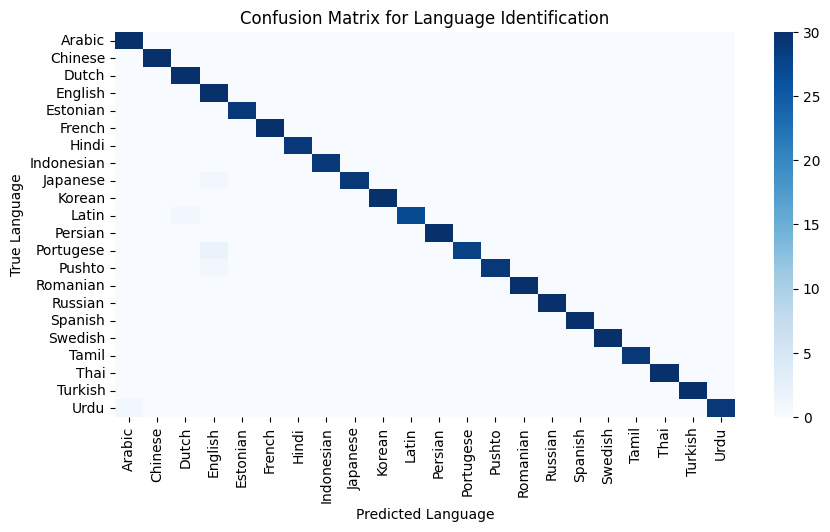

In [ ]:
# confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# read llm_pred -this is used to keep the prediction of the llm and avoid running the code when the session already closes-
with open("llm_pred.txt", "r") as f:
    llm_pred = [line.strip() for line in f.readlines()]

labels = sorted(set(df['language'].unique())) # set() is used to keep only one instance of each language and sorted() to return it as a list so list() would work just fine

cm = confusion_matrix(y_sample, llm_pred, labels=labels)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix for Language Identification")
plt.xlabel("Predicted Language")
plt.ylabel("True Language")
plt.show()

## Fix the LLM prompt for predicting non existance 'German' sample in the test samples

In [ ]:
# adding a new rule to insist the LLM to choose from the labels listes in the test samples

def strict_prompt(text):
    return f"""
You are a linguistic analysis model specialized in identifying languages based on:
- Alphabet and script patterns
- Character frequency
- Word morphology
- Common phrases
- Punctuation and writing direction

Your task:
Determine the language of the text below with high confidence.

Rules:
- Do NOT translate the text.
- Do NOT explain your reasoning.
- Do NOT output sentences.
- Output ONLY the language label.
- Choose only from the Allowed labels.

Allowed labels:
Estonian, Swedish, Thai, Tamil, Dutch, Japanese, Turkish, Latin, Urdu
Indonesian, Portugese, French, Chinese, Korean, Hindi, Spanish, Pushto, Persian
Romanian, Russian, English, Arabic

Here are example language identifications:
Text: "la real colegiata y basílica de san isidoro"
Language: Spanish

Text:"ہلی جماعت سے پانچویں جماعت تک درس دینے والے دو اسکول ہیں۔ ایک میں ذریعہ تعلیم اردو ہے دوسری میں تلگو"
Language: Urdu

Text to analyze:
"{text}"

Return only the language label.
"""

In [ ]:
# sample only 2 test samples of each language (two samples per language) from y_test, X_test
import pandas as pd

# let X_test and y_test into a single DataFrame to sample from
test_df = pd.DataFrame({
    "text": X_test,
    "language": y_test
})

# Sample only 2 examples per language
strict_prompt_sample_df = (
    test_df
    .groupby("language", group_keys=False) # each group a mini dataframe to sample from
    .apply(lambda x: x.sample(n=2, random_state=42))
)

# turn the columns into lists for iterations in llm batch function
X_sample_strict = strict_prompt_sample_df["text"].tolist()
y_sample_strict = strict_prompt_sample_df["language"].tolist()

strict_prompt_sample_df


/tmp/ipykernel_1301/941071790.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=2, random_state=42))


,text,language
9111,بعد تأخير تكرر لمرتين على الموعد النهائي للتحو...,Arabic
17450,المنظومات التمثيلية analog systems يتم في هذه ...,Arabic
2609,年，邓斯特出演了奇幻片《逃出魔幻紀》，该片一定程度上是根据克里斯·凡·艾斯伯格年的同名短篇故...,Chinese
227,历史上的柔远驿是为了给琉球贡使及随员提供食宿之所，同时它也成为中琉间商业和文化交流的枢纽。琉...,Chinese
17771,zijn streven naar een machtspositie was één va...,Dutch
536,de stelling is berucht omdat hij zo lastig met...,Dutch
18139,stick figure is collaborating with mighty tree...,English
3077,most of the population as of speaks french o...,English
11777,audrey hepburn sündinud audrey kathleen ruston...,Estonian
3294,katoliku kiriku dogmad on kinnitatud mõne kiri...,Estonian


In [ ]:
# apply testing samples to deepseek-v4-pro

# 2 samples per language, with 22 languages = 2 * 22 = 44 testing samples

# run llm pred
llm_pred_strict = llm_predict_batch(X_sample_strict)

Processing sample 1/44...
Processing sample 2/44...
Processing sample 3/44...
Processing sample 4/44...
Processing sample 5/44...
Processing sample 6/44...
Processing sample 7/44...
Processing sample 8/44...
Processing sample 9/44...
Processing sample 10/44...
Processing sample 11/44...
Processing sample 12/44...
Processing sample 13/44...
Processing sample 14/44...
Processing sample 15/44...
Processing sample 16/44...
Processing sample 17/44...
Processing sample 18/44...
Processing sample 19/44...
Processing sample 20/44...
Processing sample 21/44...
Processing sample 22/44...
Processing sample 23/44...
Processing sample 24/44...
Processing sample 25/44...
Processing sample 26/44...
Processing sample 27/44...
Processing sample 28/44...
Processing sample 29/44...
Processing sample 30/44...
Processing sample 31/44...
Processing sample 32/44...
Processing sample 33/44...
Processing sample 34/44...
Processing sample 35/44...
Processing sample 36/44...
Processing sample 37/44...
Processing

In [ ]:
# evaluation report
from sklearn.metrics import accuracy_score, classification_report

print("LLM Accuracy:", accuracy_score(y_sample_strict, llm_pred_strict))
print(classification_report(y_sample_strict, llm_pred_strict))

LLM Accuracy: 0.9772727272727273
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00         2
     Chinese       1.00      1.00      1.00         2
       Dutch       1.00      1.00      1.00         2
     English       0.67      1.00      0.80         2
    Estonian       1.00      1.00      1.00         2
      French       1.00      1.00      1.00         2
       Hindi       1.00      0.50      0.67         2
  Indonesian       1.00      1.00      1.00         2
    Japanese       1.00      1.00      1.00         2
      Korean       1.00      1.00      1.00         2
       Latin       1.00      1.00      1.00         2
     Persian       1.00      1.00      1.00         2
   Portugese       1.00      1.00      1.00         2
      Pushto       1.00      1.00      1.00         2
    Romanian       1.00      1.00      1.00         2
     Russian       1.00      1.00      1.00         2
     Spanish       1.00      1.00      1.00     

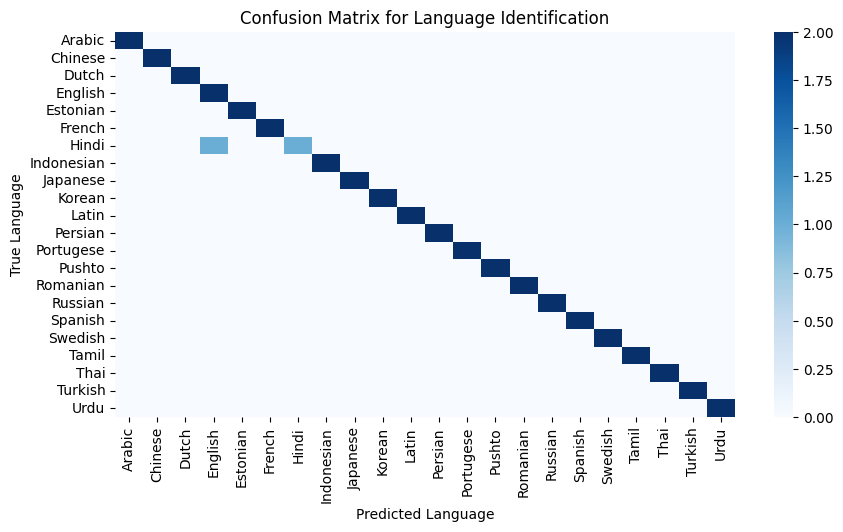

In [ ]:
# confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = sorted(set(df['language'].unique())) # set() is used to keep only one instance of each language and sorted() to return it as a list so list() would work just fine

cm = confusion_matrix(y_sample_strict, llm_pred_strict, labels=labels)

plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix for Language Identification")
plt.xlabel("Predicted Language")
plt.ylabel("True Language")
plt.show()